# Part 1 — D2C Customer Churn: Data Audit, EDA & Business Understanding

**Snapshot date:** 2025-09-30  
**Target:** Predict which customers will NOT purchase in the 60 days after the snapshot  
**Dataset:** 2,400 customers across 7 source files  
**Churn rate:** 47.0% (1,127 churned / 2,400 total)

## Setup : Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

CHARTS_DIR = "charts"
os.makedirs(CHARTS_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COLORS = {"churned": "#e05252", "retained": "#4a90d9", "neutral": "#7cb4d4"}
SNAPSHOT = pd.Timestamp("2025-09-30")
DATA_DIR  = "data"

print("Libraries loaded.")
print(f"Snapshot date: {SNAPSHOT.date()}")

Libraries loaded.
Snapshot date: 2025-09-30


---
## Section 1 : Load & Inspect All Datasets

Loading alll 7 raw files and confirming row counts, dtypes, and basic structure before any analysis.


In [3]:
customers     = pd.read_csv(f"{DATA_DIR}/customers.csv",           parse_dates=["signup_date"])
orders        = pd.read_csv(f"{DATA_DIR}/orders.csv",              parse_dates=["order_date"])
tickets       = pd.read_csv(f"{DATA_DIR}/support_tickets.csv",     parse_dates=["ticket_date"])
web           = pd.read_csv(f"{DATA_DIR}/web_events_snapshot.csv")
labels        = pd.read_csv(f"{DATA_DIR}/churn_labels.csv")
rfm           = pd.read_csv(f"{DATA_DIR}/rfm_modeling_snapshot.csv")
interventions = pd.read_csv(f"{DATA_DIR}/intervention_history.csv")

dfs = {
    "customers":       customers,
    "orders":          orders,
    "support_tickets": tickets,
    "web_events":      web,
    "churn_labels":    labels,
    "rfm_snapshot":    rfm,
    "interventions":   interventions,
}

print("File row counts:")
for name, df in dfs.items():
    print(f"{name:15s}  -  {len(df)} rows  ×  {df.shape[1]} cols")

File row counts:
customers        -  2400 rows  ×  9 cols
orders           -  10009 rows  ×  10 cols
support_tickets  -  1921 rows  ×  8 cols
web_events       -  2400 rows  ×  10 cols
churn_labels     -  2400 rows  ×  4 cols
rfm_snapshot     -  2400 rows  ×  29 cols
interventions    -  2400 rows  ×  5 cols


In [4]:
# Quick .info() for all files
for name, df in dfs.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    df.info()


customers
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          2400 non-null   object        
 1   signup_date          2400 non-null   datetime64[ns]
 2   city_tier            2400 non-null   object        
 3   age_group            2400 non-null   object        
 4   acquisition_channel  2400 non-null   object        
 5   loyalty_tier         1014 non-null   object        
 6   preferred_category   2400 non-null   object        
 7   skin_type            1999 non-null   object        
 8   marketing_consent    2400 non-null   object        
dtypes: datetime64[ns](1), object(8)
memory usage: 168.9+ KB

orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         -------

---
## Section 2 : Join Integrity

All side-tables use `customer_id` as the join key to `customers.csv`.  
Verifying that there are no orphaned keys and that all 1:1 tables contain exactly 2,400 rows.


In [5]:
cust_ids = set(customers["customer_id"])

print("Orphan customer_ids (in side-table but not in customers.csv):")
for name, df in dfs.items():
    if name == "customers":
        continue
    if "customer_id" in df.columns:
        orphans = set(df["customer_id"]) - cust_ids
        

print()
print(f"Customers WITH support tickets : {tickets['customer_id'].nunique():,}")
print(f"Customers WITHOUT tickets      : {2400 - tickets['customer_id'].nunique():,} ")

print()


print("Row count check for 1:1 tables:")
if all(len(dfs[name]) == 2400 for name in ["churn_labels", "web_events", "rfm_snapshot", "interventions"]):
    print("All datasets have 2400 rows.")
else:
    print("Not all datasets have 2400 rows.")
    

Orphan customer_ids (in side-table but not in customers.csv):

Customers WITH support tickets : 1,247
Customers WITHOUT tickets      : 1,153 

Row count check for 1:1 tables:
All datasets have 2400 rows.


---
## Section 3 : Data Quality Audit

Check for: missing values, duplicate records, invalid values, outliers,  
date consistency issues, and leakage-risk columns.


### 3A : Missing Values

In [ ]:
print("Missing values across all files:")
print("-" * 65)
for name, df in dfs.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]    #filtering out columns with zero nulls
    if len(nulls):
        for col, n in nulls.items():
            pct = n / len(df) * 100
            print(f"  {name}.{col:15s}  {n:>5,} nulls  ({pct:.1f}%)")
    else:
        print(f"  {name:25s}  — no nulls")

print()
print("Recommended Solutions:")
print("\n1 - customers.loyalty_tier (57.8% null): Not enrolled in loyalty programme.")
print("Solution - Filled with 'Not Enrolled' for analysis and encoded as own category for modelling.")
print("\n2 - customers.skin_type (16.7% null): Not self-reported.")
print("Solution - Fill with 'Unknown' as low feature importance expected.")
print("\n3 - orders.rating (0.8% null): Customer did not leave a rating.")
print("Solution - Imput with median rating per category for avg_rating features.")

Missing values across all files:
-----------------------------------------------------------------
  customers.loyalty_tier     1,386 nulls  (57.8%)
  customers.skin_type          401 nulls  (16.7%)
  orders.rating              80 nulls  (0.8%)
  support_tickets            — no nulls
  web_events                 — no nulls
  churn_labels               — no nulls
  rfm_snapshot.loyalty_tier     1,386 nulls  (57.8%)
  interventions              — no nulls

Recommended Solutions:

1 - customers.loyalty_tier (57.8% null): Not enrolled in loyalty programme.
Solution - Fill with 'Not Enrolled' for analysis; encode as own category for modelling.

2 - customers.skin_type (16.7% null): Not self-reported.
Solution - Fill with 'Unknown'; low feature importance expected.

3 - orders.rating (0.8% null): Customer did not leave a rating.
Solution - Impute with median rating per category for avg_rating features.


### 3B : Duplicate / Duplicate-Like Records

In [ ]:
dup_orders = orders[orders["order_id"].str.contains("_DUP", na=False)].copy()
print(f"order_ids ending in '_DUP': {len(dup_orders)} rows across {dup_orders['customer_id'].nunique()} customers")  #one customer might have multiple _DUP rows hence ".nunique"
print()
print(dup_orders[["order_id","customer_id","order_date","gross_amount"]].to_string(index=False))
print()
print(f"Exact duplicate rows (all columns identical): {orders.duplicated().sum()}")
print()
print("Recommended Solution: Drop _DUP rows before any feature engineering or modelling.")
print("Note: Some _DUP orders are post-snapshot (already excluded from features),")
print("      but pre-snapshot ones (e.g. CUST00848, CUST00869) must also be removed.")

order_ids ending in '_DUP': 12 rows across 11 customers

     order_id customer_id order_date  gross_amount
ORD008249_DUP   CUST00153 2025-11-04        321.31
ORD002124_DUP   CUST00628 2025-03-18        410.04
ORD002862_DUP   CUST00837 2025-07-12        952.02
ORD002916_DUP   CUST00848 2025-09-26        547.18
ORD002970_DUP   CUST00869 2024-12-22        818.64
ORD008836_DUP   CUST00875 2025-10-23        711.20
ORD003897_DUP   CUST01140 2025-04-14        769.96
ORD004577_DUP   CUST01335 2025-02-12        533.07
ORD005451_DUP   CUST01601 2024-11-07       1160.41
ORD005529_DUP   CUST01621 2024-08-12        339.33
ORD006220_DUP   CUST01820 2025-01-22        562.71
ORD009518_DUP   CUST01820 2025-10-16        802.18

Exact duplicate rows (all columns identical): 0

Treatment: Drop _DUP rows before any feature engineering or modelling.
Note: Some _DUP orders are post-snapshot (already excluded from features),
      but pre-snapshot ones (e.g. CUST00848, CUST00869) must also be removed.


### 3C : Post-Snapshot Orders (Leakage Risk)

In [8]:
pre_orders  = orders[orders["order_date"] <= SNAPSHOT].copy()
post_orders = orders[orders["order_date"] >  SNAPSHOT].copy()

print(f"Pre-snapshot orders  (Used as Features): {len(pre_orders):,}")
print(f"Post-snapshot orders (Used as Label construction ONLY): {len(post_orders):,}")
# print()
# print("Value ranges in pre-snapshot data:")
# for col, lo, hi in [("discount_pct","0.00","0.70"),("quantity","1","4"),
#                      ("delivery_days","1","11"),("returned","0","1")]:
#     actual_lo = pre_orders[col].min()
#     actual_hi = pre_orders[col].max()
#     print(f"  {col:20s}  actual: {actual_lo} – {actual_hi}  expected: {lo} – {hi}")

Pre-snapshot orders  (Used as Features): 8,137
Post-snapshot orders (Used as Label construction ONLY): 1,872


### 3D : Outliers
Classic IQR-based outlier detection

gross_amount statistics (pre-snapshot):
count     8137.00
mean       752.02
std        626.18
min        149.00
25%        431.83
50%        598.12
75%        922.91
max      24789.38
Name: gross_amount, dtype: float64

IQR-based upper fence (Q3 + 3×IQR) : Rs2,396.15
Note: 3*IQR choosen as fence since high spenders are real customers, not errors.

Records above fence                 : 73
Max value                           : Rs24,789.38
99th percentile                     : Rs2,342.97


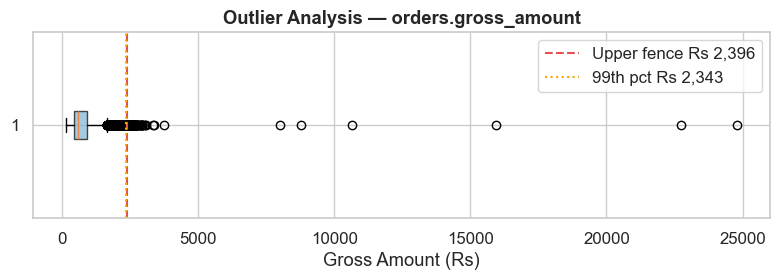

In [14]:
ga   = pre_orders["gross_amount"]
q1   = ga.quantile(0.25)
q3   = ga.quantile(0.75)
iqr  = q3 - q1
fence = q3 + 3 * iqr
outliers = pre_orders[ga > fence]

print(f"gross_amount statistics (pre-snapshot):")
print(ga.describe().round(2))
print()
print(f"IQR-based upper fence (Q3 + 3×IQR) : Rs{fence:,.2f}")                                   #3*IQR choosen as fence since high spenders are real customers, not errors
print("Note: 3*IQR choosen as fence since high spenders are real customers, not errors.")
print(f"\nRecords above fence                 : {len(outliers):,}")
print(f"Max value                           : Rs{ga.max():,.2f}")
print(f"99th percentile                     : Rs{ga.quantile(0.99):,.2f}")

# Box plot
fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(ga, vert=False, patch_artist=True,
           boxprops=dict(facecolor="#7cb4d4", alpha=0.7))
ax.axvline(fence, color="#e05252", linestyle="--", linewidth=1.5, label=f"Upper fence Rs {fence:,.0f}")
ax.axvline(ga.quantile(0.99), color="orange", linestyle=":", linewidth=1.5, label="99th pct Rs 2,343")
ax.set_xlabel("Gross Amount (Rs)")
ax.set_title("Outlier Analysis — orders.gross_amount", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart0_outliers.png", dpi=150, bbox_inches="tight")
plt.show()


### 3E : Date Consistency

In [18]:
print("Date consistency checks:")
print(f"  customers.signup_date range  : {customers['signup_date'].min().date()} – {customers['signup_date'].max().date()}")
print(f"  Signups after snapshot date  : {(customers['signup_date'] > SNAPSHOT).sum()}")
print(f"  tickets.ticket_date range    : {tickets['ticket_date'].min().date()} – {tickets['ticket_date'].max().date()}")
print(f"  Ticket dates after snapshot  : {(tickets['ticket_date'] > SNAPSHOT).sum()}")
print()
for name, col in [("web_events","snapshot_date"),("churn_labels","snapshot_date"),
                   ("rfm_snapshot","snapshot_date"),("interventions","snapshot_date")]:
    vals = dfs[name][col].unique().tolist()
    ok = "" if vals == ["2025-09-30"] else "Error"
    print(f"  {name}.{col}: {vals}  {ok}")
print()
print("All snapshot_date fields are consistently 2025-09-30.")
print("No tickets or signups fall outside the valid date range.")

Date consistency checks:
  customers.signup_date range  : 2024-01-01 – 2025-09-15
  Signups after snapshot date  : 0
  tickets.ticket_date range    : 2024-01-13 – 2025-09-30
  Ticket dates after snapshot  : 0

  web_events.snapshot_date: ['2025-09-30']  
  churn_labels.snapshot_date: ['2025-09-30']  
  rfm_snapshot.snapshot_date: ['2025-09-30']  
  interventions.snapshot_date: ['2025-09-30']  

All snapshot_date fields are consistently 2025-09-30.
No tickets or signups fall outside the valid date range.


### 3F: Leakage-Risk Columns

In [19]:
leakage_risks = [
    ("orders.csv",        "order_date > 2025-09-30",
     "Post-snapshot orders are in the churn target window — using them reveals the label directly"),
    ("churn_labels.csv",  "churn_next_60d",
     "This IS the target variable — must never appear as a model input feature"),
    ("rfm_snapshot.csv",  "churn_next_60d",
     "Same target variable is embedded in the RFM snapshot file — exclude before modelling"),
    ("churn_labels.csv",  "split",
     "Train/val/test assignment — metadata, not a predictive signal"),
    ("rfm_snapshot.csv",  "snapshot_date",
     "Constant field (all 2025-09-30) — zero predictive value, exclude from feature matrix"),
]

print(f"{'File':<22} {'Column':<35} {'Risk'}")
print("-" * 90)
for f, col, reason in leakage_risks:
    print(f"  {f:<20} {col:<33} {reason}")

File                   Column                              Risk
------------------------------------------------------------------------------------------
  orders.csv           order_date > 2025-09-30           Post-snapshot orders are in the churn target window — using them reveals the label directly
  churn_labels.csv     churn_next_60d                    This IS the target variable — must never appear as a model input feature
  rfm_snapshot.csv     churn_next_60d                    Same target variable is embedded in the RFM snapshot file — exclude before modelling
  churn_labels.csv     split                             Train/val/test assignment — metadata, not a predictive signal
  rfm_snapshot.csv     snapshot_date                     Constant field (all 2025-09-30) — zero predictive value, exclude from feature matrix


---
## Section 4: Churn Distribution

The dataset is well-balanced: 47.0% churned (1,127) and 53.0% retained (1,273).  
The train/validation/test split is pre-assigned and balanced within each split.


Not Churned (0): 1,273  (53.0%)
Churned     (1): 1,127  (47.0%)
Overall churn rate: 47.0%

Split breakdown:
churn_next_60d    0    1
split                   
test            168  168
train           916  812
validation      189  147


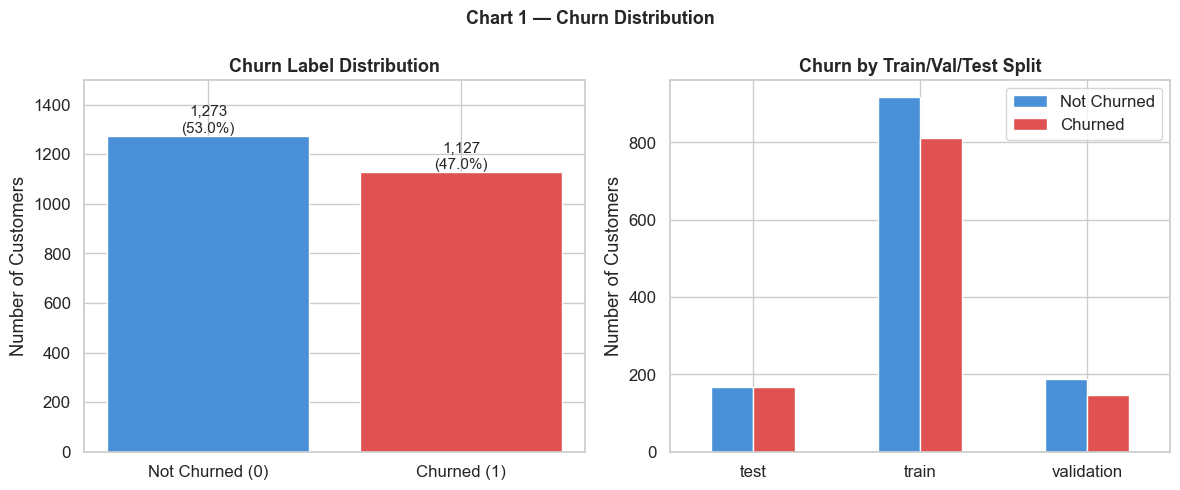

In [20]:
churn_counts = labels["churn_next_60d"].value_counts().sort_index()
print(f"Not Churned (0): {churn_counts[0]:,}  ({churn_counts[0]/2400:.1%})")
print(f"Churned     (1): {churn_counts[1]:,}  ({churn_counts[1]/2400:.1%})")
print(f"Overall churn rate: {labels['churn_next_60d'].mean():.1%}")
print()
print("Split breakdown:")
print(labels.groupby(["split","churn_next_60d"]).size().unstack())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(["Not Churned (0)", "Churned (1)"], churn_counts.values,
            color=[COLORS["retained"], COLORS["churned"]], edgecolor="white")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 15, f"{v:,}\n({v/2400:.1%})", ha="center", fontsize=11)
axes[0].set_title("Churn Label Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Customers")
axes[0].set_ylim(0, 1500)

split_churn = labels.groupby(["split","churn_next_60d"]).size().unstack()
split_churn.plot(kind="bar", ax=axes[1],
                 color=[COLORS["retained"], COLORS["churned"]], edgecolor="white", rot=0)
axes[1].set_title("Churn by Train/Val/Test Split", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Number of Customers")
axes[1].legend(["Not Churned","Churned"])
axes[1].set_xlabel("")

plt.suptitle("Chart 1 — Churn Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart1_churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 5 - Customer Demographics & Profile

**Key finding:** Acquisition channel and loyalty tier are the strongest demographic signals.  
Organic (39.8%) and Referral (42.2%) customers churn 7–10 pp below Google Search (50.4%).  
Platinum loyalty members churn at only 37.1% vs 48.3% for non-enrolled.


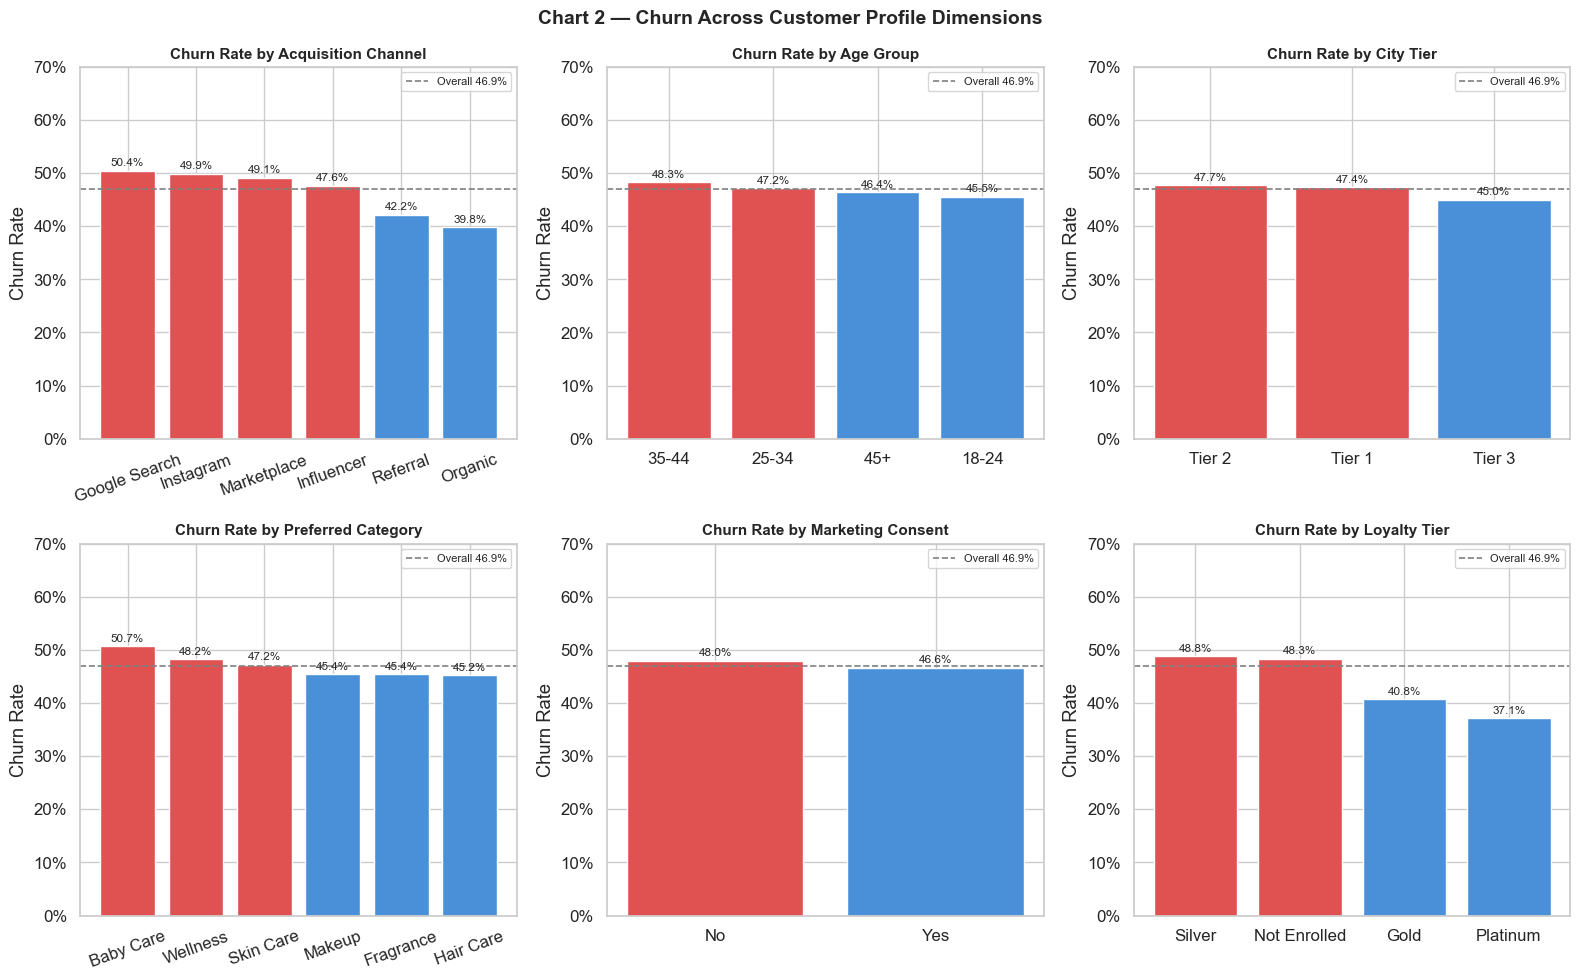

Business insights:
  • Organic & Referral are the most valuable acquisition channels (lower churn)
  • Loyalty programme clearly reduces churn — Platinum 37.1% vs Not Enrolled 48.3%
  • Marketing consent has minimal churn differential - re-examine email strategy


In [22]:
master = customers.merge(labels, on="customer_id")
master["days_since_signup"] = (SNAPSHOT - master["signup_date"]).dt.days
master_lt = master.copy()
master_lt["loyalty_tier"] = master_lt["loyalty_tier"].fillna("Not Enrolled")

def churn_bar(ax, df, col, title, rotate=0):
    g = df.groupby(col)["churn_next_60d"].agg(
        churn_rate="mean", count="count"
    ).reset_index().sort_values("churn_rate", ascending=False)
    bars = ax.bar(g[col], g["churn_rate"],
                  color=[COLORS["churned"] if r > 0.47 else COLORS["retained"]
                         for r in g["churn_rate"]], edgecolor="white")
    ax.axhline(labels["churn_next_60d"].mean(), color="gray", linestyle="--",
               linewidth=1.2, label="Overall 46.9%")
    for bar, (_, row) in zip(bars, g.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{row['churn_rate']:.1%}",
                ha="center", va="bottom", fontsize=8.5)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Churn Rate")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylim(0, 0.70)
    ax.legend(fontsize=8)
    if rotate: ax.tick_params(axis="x", rotation=rotate)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
churn_bar(axes[0,0], master,    "acquisition_channel", "Churn Rate by Acquisition Channel", rotate=20)
churn_bar(axes[0,1], master,    "age_group",           "Churn Rate by Age Group")
churn_bar(axes[0,2], master,    "city_tier",           "Churn Rate by City Tier")
churn_bar(axes[1,0], master,    "preferred_category",  "Churn Rate by Preferred Category", rotate=20)
churn_bar(axes[1,1], master,    "marketing_consent",   "Churn Rate by Marketing Consent")
churn_bar(axes[1,2], master_lt, "loyalty_tier",        "Churn Rate by Loyalty Tier")

plt.suptitle("Chart 2 — Churn Across Customer Profile Dimensions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart2_demographic_churn.png", dpi=150, bbox_inches="tight")
plt.show()

print("Business insights:")
print("  • Organic & Referral are the most valuable acquisition channels (lower churn)")
print("  • Loyalty programme clearly reduces churn — Platinum 37.1% vs Not Enrolled 48.3%")
print("  • Marketing consent has minimal churn differential - re-examine email strategy")

---
## Section 6 : Order Behaviour & Monetary Analysis

**Key finding:** Recency (days since last order) is the single most predictive feature (r=0.561).  
Customers who last ordered 180+ days ago churn at 91.4%. Those who ordered in the last 30 days churn at only 11.9%.


Churn rate by recency bucket:
recency_bucket  churn_rate  count
     0–30 days    0.119225    671
    31–60 days    0.303855    441
    61–90 days    0.457064    361
   91–180 days    0.787270    597
     180+ days    0.913907    302


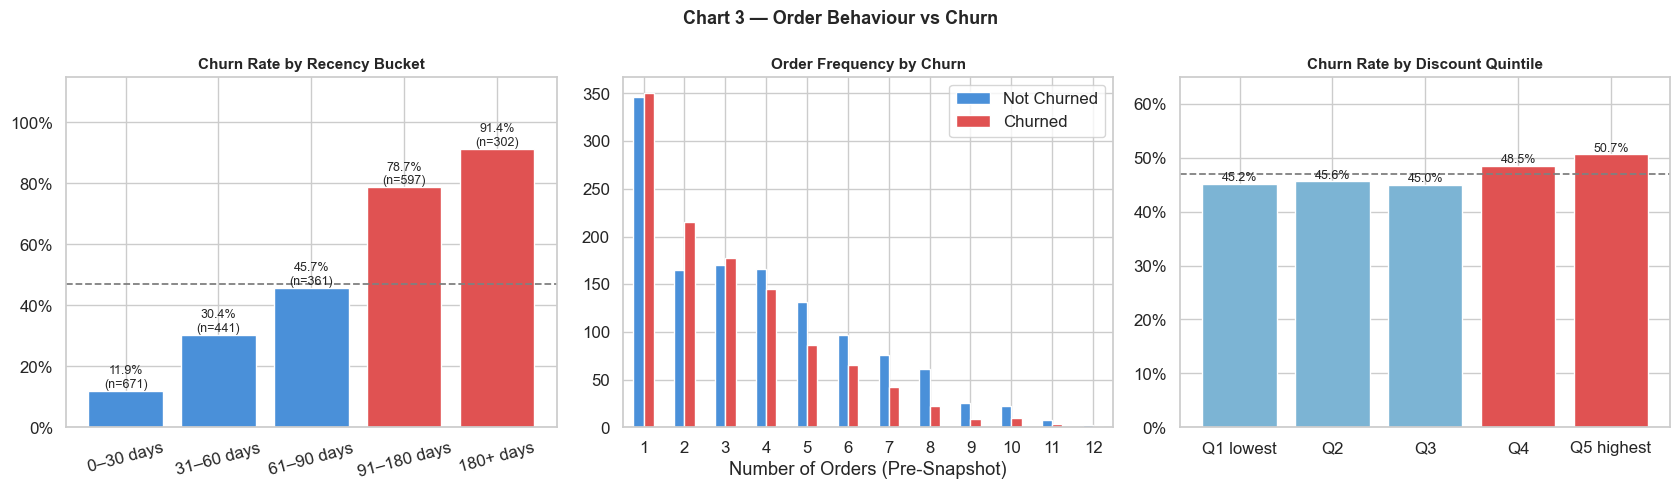

In [23]:
# Recency
last_order_pre = pre_orders.groupby("customer_id")["order_date"].max().reset_index()
last_order_pre["recency_days"] = (SNAPSHOT - last_order_pre["order_date"]).dt.days
master2 = master.merge(last_order_pre[["customer_id","recency_days"]], on="customer_id", how="left")

bins    = [0, 30, 60, 90, 180, 9999]
blabels = ["0–30 days","31–60 days","61–90 days","91–180 days","180+ days"]
master2["recency_bucket"] = pd.cut(master2["recency_days"], bins=bins, labels=blabels)

recency_g = master2.groupby("recency_bucket", observed=True)["churn_next_60d"].agg(
    churn_rate="mean", count="count").reset_index()
print("Churn rate by recency bucket:")
print(recency_g.to_string(index=False))

# Order aggregates
order_agg = pre_orders.groupby("customer_id").agg(
    order_count=("order_id",    "count"),
    total_spend=("gross_amount","sum"),
    avg_disc   =("discount_pct","mean"),
    return_rate=("returned",    "mean"),
).reset_index()
master3 = master2.merge(order_agg, on="customer_id", how="left")
master3["disc_bucket"] = pd.qcut(
    master3["avg_disc"].fillna(master3["avg_disc"].median()), 5,
    labels=["Q1 lowest","Q2","Q3","Q4","Q5 highest"]
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Recency
axes[0].bar(recency_g["recency_bucket"], recency_g["churn_rate"],
            color=[COLORS["churned"] if r > 0.47 else COLORS["retained"]
                   for r in recency_g["churn_rate"]], edgecolor="white")
axes[0].axhline(labels["churn_next_60d"].mean(), color="gray", linestyle="--", linewidth=1.3)
for i, row in recency_g.iterrows():
    axes[0].text(list(recency_g.index).index(i), row["churn_rate"]+0.01,
                 f"{row['churn_rate']:.1%}\n(n={row['count']})", ha="center", fontsize=9)
axes[0].set_title("Churn Rate by Recency Bucket", fontsize=11, fontweight="bold")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_ylim(0, 1.15)
axes[0].tick_params(axis="x", rotation=15)

# Frequency
freq_g = master3.groupby(["order_count","churn_next_60d"]).size().unstack(fill_value=0)
freq_g = freq_g[freq_g.index <= 12]
freq_g.plot(kind="bar", ax=axes[1],
            color=[COLORS["retained"], COLORS["churned"]], edgecolor="white", rot=0)
axes[1].set_title("Order Frequency by Churn", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Number of Orders (Pre-Snapshot)")
axes[1].legend(["Not Churned","Churned"])

# Discount quintile
disc_g = master3.groupby("disc_bucket", observed=True)["churn_next_60d"].mean().reset_index()
axes[2].bar(disc_g["disc_bucket"], disc_g["churn_next_60d"],
            color=[COLORS["churned"] if r > 0.47 else COLORS["neutral"]
                   for r in disc_g["churn_next_60d"]], edgecolor="white")
axes[2].axhline(labels["churn_next_60d"].mean(), color="gray", linestyle="--", linewidth=1.3)
for i, row in disc_g.iterrows():
    axes[2].text(list(disc_g.index).index(i), row["churn_next_60d"]+0.005,
                 f"{row['churn_next_60d']:.1%}", ha="center", fontsize=9)
axes[2].set_title("Churn Rate by Discount Quintile", fontsize=11, fontweight="bold")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].set_ylim(0, 0.65)

plt.suptitle("Chart 3 — Order Behaviour vs Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart3_order_behaviour.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 7 : Return / Refund Behaviour

Churned customers have a higher average return rate (8.2%) vs retained customers (5.5%).  
High return rates signal product dissatisfaction — a meaningful secondary churn signal.


Return rate by churn status:
                 mean  median
churn_next_60d               
0               0.055     0.0
1               0.082     0.0


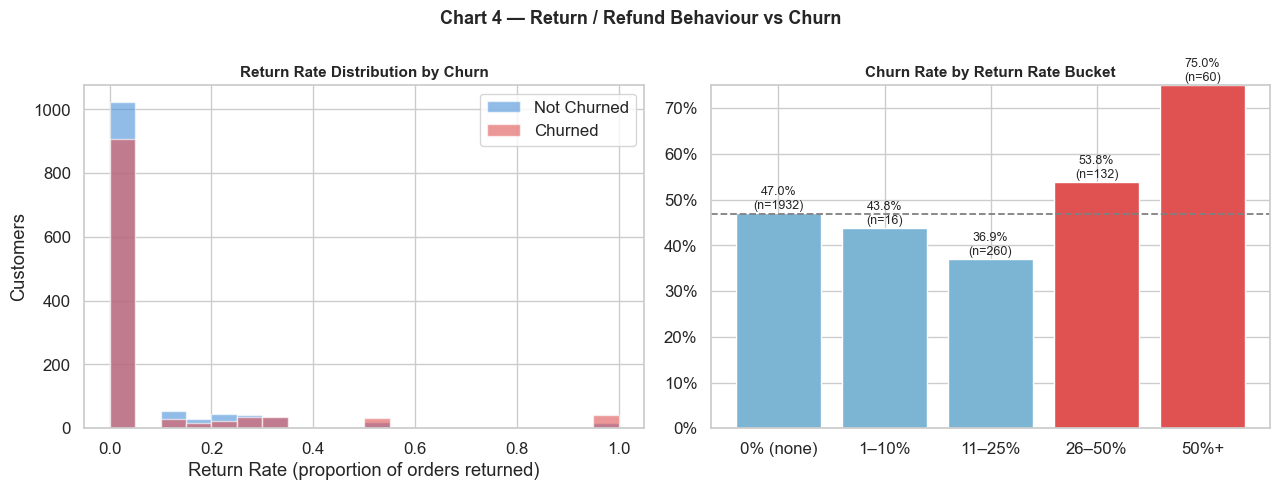

In [24]:
print("Return rate by churn status:")
print(master3.groupby("churn_next_60d")["return_rate"].agg(["mean","median"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for val, color, label in [(0, COLORS["retained"],"Not Churned"), (1, COLORS["churned"],"Churned")]:
    d = master3.loc[master3["churn_next_60d"]==val, "return_rate"].fillna(0)
    axes[0].hist(d, bins=20, alpha=0.6, color=color, label=label, edgecolor="white")
axes[0].set_title("Return Rate Distribution by Churn", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Return Rate (proportion of orders returned)")
axes[0].set_ylabel("Customers")
axes[0].legend()

master3["return_bucket"] = pd.cut(master3["return_rate"].fillna(0),
    bins=[-0.001,0,0.1,0.25,0.5,1.01],
    labels=["0% (none)","1–10%","11–25%","26–50%","50%+"])
ret_g = master3.groupby("return_bucket", observed=True)["churn_next_60d"].agg(
    churn_rate="mean", count="count").reset_index()
axes[1].bar(ret_g["return_bucket"], ret_g["churn_rate"],
            color=[COLORS["churned"] if r>0.47 else COLORS["neutral"] for r in ret_g["churn_rate"]],
            edgecolor="white")
axes[1].axhline(labels["churn_next_60d"].mean(), color="gray", linestyle="--", linewidth=1.3)
for i, row in ret_g.iterrows():
    axes[1].text(i, row["churn_rate"]+0.01, f"{row['churn_rate']:.1%}\n(n={row['count']})",
                 ha="center", fontsize=9)
axes[1].set_title("Churn Rate by Return Rate Bucket", fontsize=11, fontweight="bold")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_ylim(0, 0.75)

plt.suptitle("Chart 4 — Return / Refund Behaviour vs Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart4_return_behaviour.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 8 : Support Ticket Analysis

1,247 customers (51.9%) raised at least one support ticket.  
**Surprise finding:** Churned customers actually raised *fewer* tickets on average (0.74 vs 0.85).  
This suggests silent churners — customers who don't complain, they just leave.  
Sentiment is consistently negative for both groups (overall avg ≈ -0.43).


Support ticket metrics by churn:
                ticket_count  avg_sentiment  neg_ticket_rate
churn_next_60d                                              
0                      0.852         -0.428            0.790
1                      0.742         -0.440            0.798


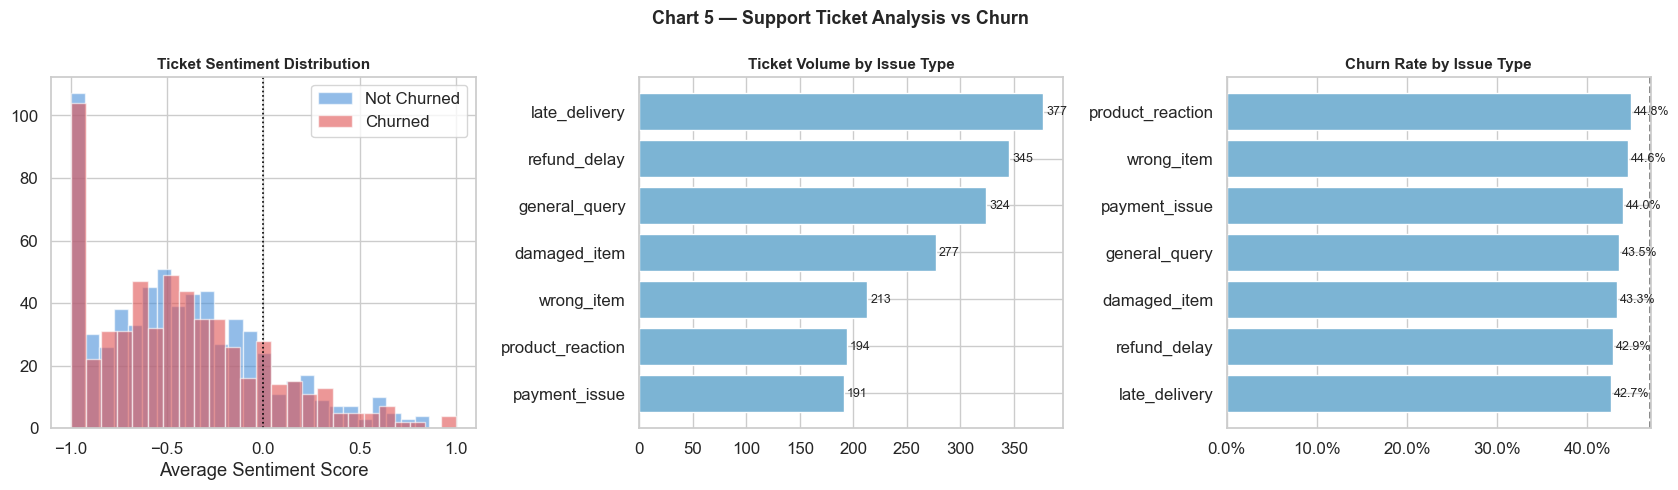

In [25]:
ticket_agg = tickets.groupby("customer_id").agg(
    ticket_count    =("ticket_id",       "count"),
    avg_sentiment   =("sentiment_score", "mean"),
    neg_ticket_rate =("sentiment_score", lambda x: (x<0).mean()),
    avg_resolution  =("resolution_hours","mean"),
    reopened_rate   =("reopened",        "mean"),
).reset_index()

master4 = master3.merge(ticket_agg, on="customer_id", how="left")
master4["ticket_count"] = master4["ticket_count"].fillna(0)

print("Support ticket metrics by churn:")
print(master4.groupby("churn_next_60d")[
    ["ticket_count","avg_sentiment","neg_ticket_rate"]].mean().round(3))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for val, color, label in [(0,COLORS["retained"],"Not Churned"),(1,COLORS["churned"],"Churned")]:
    d = master4.loc[(master4["churn_next_60d"]==val) & master4["avg_sentiment"].notna(), "avg_sentiment"]
    axes[0].hist(d, bins=25, alpha=0.6, color=color, label=label, edgecolor="white")
axes[0].axvline(0, color="black", linestyle=":", linewidth=1.2)
axes[0].set_title("Ticket Sentiment Distribution", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Average Sentiment Score")
axes[0].legend()

issue_counts = tickets["issue_type"].value_counts()
axes[1].barh(issue_counts.index, issue_counts.values, color=COLORS["neutral"], edgecolor="white")
for i, v in enumerate(issue_counts.values):
    axes[1].text(v+3, i, str(v), va="center", fontsize=9)
axes[1].set_title("Ticket Volume by Issue Type", fontsize=11, fontweight="bold")
axes[1].invert_yaxis()

issue_churn = tickets.merge(labels, on="customer_id")
ic_g = issue_churn.groupby("issue_type")["churn_next_60d"].mean().sort_values(ascending=False)
axes[2].barh(ic_g.index, ic_g.values,
             color=[COLORS["churned"] if r>0.47 else COLORS["neutral"] for r in ic_g.values],
             edgecolor="white")
axes[2].axvline(labels["churn_next_60d"].mean(), color="gray", linestyle="--", linewidth=1.3)
for i, (iss, rate) in enumerate(ic_g.items()):
    axes[2].text(rate+0.003, i, f"{rate:.1%}", va="center", fontsize=9)
axes[2].set_title("Churn Rate by Issue Type", fontsize=11, fontweight="bold")
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].invert_yaxis()

plt.suptitle("Chart 5 — Support Ticket Analysis vs Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart5_support_tickets.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 9 : Web / App Activity

Web activity is the second strongest churn signal after recency.  
`last_visit_days_ago` has a 0.527 correlation with churn.  
Churned customers visited on average **26.6 days** before the snapshot; retained customers just **9.8 days**.


Web activity averages by churn:
                sessions_30d  product_views_30d  last_visit_days_ago  \
churn_next_60d                                                         
0                       6.73              28.38                 9.77   
1                       4.02              16.97                26.55   

                abandoned_carts_30d  
churn_next_60d                       
0                              0.85  
1                              0.47  


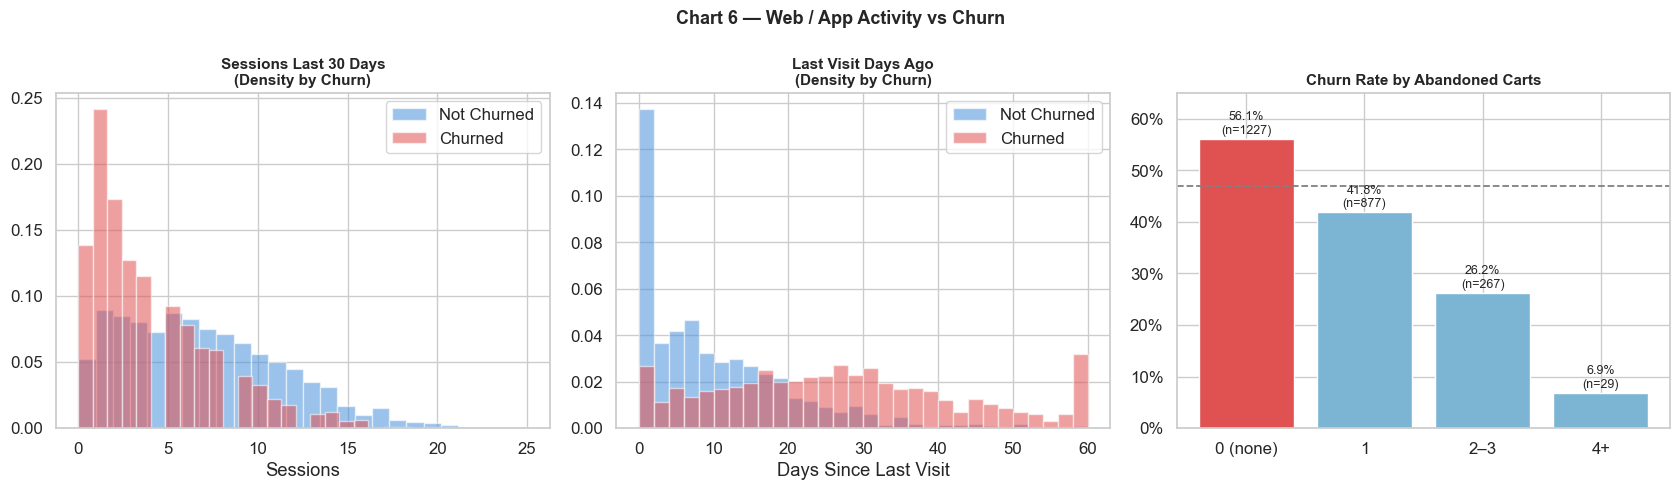


Key insight: Customers with 0 sessions in last 30 days:
churn_next_60d
0     5.0%
1    11.2%
Name: sessions_30d, dtype: object


In [26]:
master5 = master4.merge(web, on="customer_id", how="left")

print("Web activity averages by churn:")
print(master5.groupby("churn_next_60d")[
    ["sessions_30d","product_views_30d","last_visit_days_ago","abandoned_carts_30d"]
].mean().round(2))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for val, color, label in [(0,COLORS["retained"],"Not Churned"),(1,COLORS["churned"],"Churned")]:
    d = master5.loc[master5["churn_next_60d"]==val, "sessions_30d"]
    axes[0].hist(d, bins=26, alpha=0.55, color=color, label=label, edgecolor="white", density=True)
axes[0].set_title("Sessions Last 30 Days\n(Density by Churn)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Sessions")
axes[0].legend()

for val, color, label in [(0,COLORS["retained"],"Not Churned"),(1,COLORS["churned"],"Churned")]:
    d = master5.loc[master5["churn_next_60d"]==val, "last_visit_days_ago"]
    axes[1].hist(d, bins=30, alpha=0.55, color=color, label=label, edgecolor="white", density=True)
axes[1].set_title("Last Visit Days Ago\n(Density by Churn)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Days Since Last Visit")
axes[1].legend()

master5["abandon_bucket"] = pd.cut(master5["abandoned_carts_30d"],
    bins=[-1,0,1,3,100], labels=["0 (none)","1","2–3","4+"])
ab_g = master5.groupby("abandon_bucket", observed=True)["churn_next_60d"].agg(
    churn_rate="mean", count="count").reset_index()
axes[2].bar(ab_g["abandon_bucket"], ab_g["churn_rate"],
            color=[COLORS["churned"] if r>0.47 else COLORS["neutral"] for r in ab_g["churn_rate"]],
            edgecolor="white")
axes[2].axhline(labels["churn_next_60d"].mean(), color="gray", linestyle="--", linewidth=1.3)
for i, row in ab_g.iterrows():
    axes[2].text(i, row["churn_rate"]+0.01,
                 f"{row['churn_rate']:.1%}\n(n={row['count']})", ha="center", fontsize=9)
axes[2].set_title("Churn Rate by Abandoned Carts", fontsize=11, fontweight="bold")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].set_ylim(0, 0.65)

plt.suptitle("Chart 6 — Web / App Activity vs Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart6_web_activity.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey insight: Customers with 0 sessions in last 30 days:")
zero_sess = master5.groupby("churn_next_60d")["sessions_30d"].apply(lambda x: (x==0).mean())
print(zero_sess.apply(lambda x: f"{x:.1%}"))

---
## Section 10 : Campaign / Intervention History

**Key finding:** The CRM's manual priority bucket is a strong predictor of actual churn — 
`high` priority customers actually churn at **74.7%**, `low` at only **10.0%**.  
This validates the CRM team's intuition but also reveals that `new_launch` campaigns (51.0% churn) 
are the least effective retention intervention.


Churn by campaign type:
                         mean  count
last_campaign_received              
bundle_discount         0.469    473
free_shipping           0.463    469
new_launch              0.510    498
none                    0.452    507
welcome_offer           0.453    453

Churn by CRM manual priority bucket:
                         mean  count
manual_priority_bucket              
high                    0.747   1163
low                     0.100    488
medium                  0.279    749


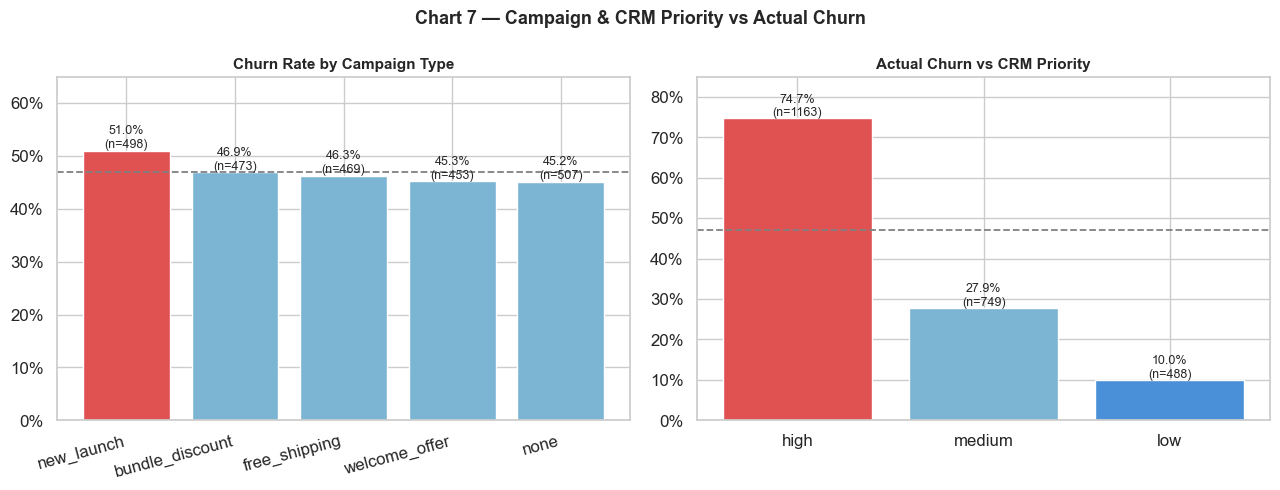

In [27]:
master6 = master5.merge(interventions, on="customer_id", how="left")

print("Churn by campaign type:")
print(master6.groupby("last_campaign_received")["churn_next_60d"].agg(["mean","count"]).round(3))
print()
print("Churn by CRM manual priority bucket:")
print(master6.groupby("manual_priority_bucket")["churn_next_60d"].agg(["mean","count"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

camp_g = master6.groupby("last_campaign_received")["churn_next_60d"].agg(
    churn_rate="mean", count="count").reset_index().sort_values("churn_rate", ascending=False)
bars = axes[0].bar(range(len(camp_g)), camp_g["churn_rate"],
                   color=[COLORS["churned"] if r>0.47 else COLORS["neutral"]
                          for r in camp_g["churn_rate"]], edgecolor="white")
axes[0].set_xticks(range(len(camp_g)))
axes[0].set_xticklabels(camp_g["last_campaign_received"], rotation=15, ha="right")
axes[0].axhline(labels["churn_next_60d"].mean(), color="gray", linestyle="--", linewidth=1.3)
for i, row in enumerate(camp_g.itertuples()):
    axes[0].text(i, row.churn_rate+0.005, f"{row.churn_rate:.1%}\n(n={row.count})",
                 ha="center", fontsize=9)
axes[0].set_title("Churn Rate by Campaign Type", fontsize=11, fontweight="bold")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_ylim(0, 0.65)

prio_g = master6.groupby("manual_priority_bucket")["churn_next_60d"].agg(
    churn_rate="mean", count="count").reset_index()
prio_g = prio_g.set_index("manual_priority_bucket").loc[["high","medium","low"]].reset_index()
axes[1].bar(prio_g["manual_priority_bucket"], prio_g["churn_rate"],
            color=[COLORS["churned"], COLORS["neutral"], COLORS["retained"]], edgecolor="white")
axes[1].axhline(labels["churn_next_60d"].mean(), color="gray", linestyle="--", linewidth=1.3)
for i, row in prio_g.iterrows():
    axes[1].text(i, row["churn_rate"]+0.005,
                 f"{row['churn_rate']:.1%}\n(n={row['count']})", ha="center", fontsize=9)
axes[1].set_title("Actual Churn vs CRM Priority", fontsize=11, fontweight="bold")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_ylim(0, 0.85)

plt.suptitle("Chart 7 — Campaign & CRM Priority vs Actual Churn", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart7_campaign_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 11 : Feature Correlation Analysis

Using the pre-built `rfm_modeling_snapshot.csv` feature matrix to understand which signals  
have the strongest linear relationship with churn.

**Top predictors:**
| Feature | Correlation | Direction |
|---|---|---|
| `recency_days` | +0.561 | Higher recency - more churn |
| `last_visit_days_ago` | +0.527 | Longer absence - more churn |
| `frequency_180d` | -0.394 | More orders - less churn |
| `monetary_180d` | -0.385 | Higher spend - less churn |
| `sessions_30d` | -0.307 | More sessions - less churn |


In [ ]:
key_cols = [
    "recency_days","frequency_180d","monetary_180d",
    "return_rate_180d","avg_discount_pct_180d","avg_rating_180d",
    "ticket_count_90d","negative_ticket_rate_90d",
    "sessions_30d","product_views_30d","last_visit_days_ago",
    "campaign_clicks_30d","churn_next_60d"
]
corr_matrix = rfm[key_cols].corr()
churn_corr  = corr_matrix["churn_next_60d"].drop("churn_next_60d").sort_values()

print("Correlation with churn_next_60d:")
for feat, val in churn_corr.items():
    direction = "→ more churn" if val > 0 else "→ less churn"
    print(f"  {feat:35s}  {val:+.3f}  {direction}")

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr_matrix, mask=mask, ax=axes[0], cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", linewidths=0.3, linecolor="white", annot_kws={"size":8})
axes[0].set_title("Feature Correlation Matrix", fontsize=11, fontweight="bold")
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", labelsize=8)

colors = [COLORS["churned"] if v>0 else COLORS["retained"] for v in churn_corr.values]
axes[1].barh(churn_corr.index, churn_corr.values, color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
for i, v in enumerate(churn_corr.values):
    axes[1].text(v+(0.005 if v>=0 else -0.005), i, f"{v:.3f}",
                 va="center", ha="left" if v>=0 else "right", fontsize=9)
axes[1].set_title("Correlation with Churn\n(Red=positive, Blue=negative)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Pearson Correlation")

plt.suptitle("Chart 8 — Feature Correlation Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart8_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 12 : Five Churn-Risk Hypotheses

Each hypothesis is supported by specific numbers from this dataset.


In [28]:
import textwrap

hypotheses = [
    {
        "id": "H1",
        "title": "Recency is the single strongest churn predictor (r=0.561)",
        "evidence": (
            "Churn rate by recency bucket: 0-30d=11.9%, 31-60d=30.4%, 61-90d=45.7%, "
            "91-180d=78.7%, 180+d=91.4%. Customers dormant for 3+ months are almost "
            "certain to churn. This is the most actionable single signal."
        ),
        "action": "Trigger automated outreach for any customer with recency > 60 days."
    },
    {
        "id": "H2",
        "title": "Web inactivity predicts churn independently of order recency (r=0.527)",
        "evidence": (
            "Churned customers averaged only 4.0 sessions in the last 30 days vs 6.7 "
            "for retained (+67% difference). 11.2% of churned customers had ZERO sessions "
            "vs just 5.0% of retained. last_visit_days_ago: churned avg=26.6 days, "
            "retained avg=9.8 days."
        ),
        "action": "Zero sessions in 14 days → trigger re-engagement email regardless of order history."
    },
    {
        "id": "H3",
        "title": "Loyalty programme non-enrolment is the largest addressable churn risk pool",
        "evidence": (
            "57.8% of customers (1,386 of 2,400) have no loyalty tier. They churn at 48.3%. "
            "Platinum members churn at only 37.1% — an 11.2 pp gap. Enrolling even 20% of "
            "unregistered customers at Platinum-level engagement could save ~31 customers from churning."
        ),
        "action": "Launch loyalty enrolment drive targeting non-enrolled customers with recency > 45 days."
    },
    {
        "id": "H4",
        "title": "Organic and Referral channels produce significantly more loyal customers",
        "evidence": (
            "Google Search: 50.4% churn. Instagram: 49.9%. Marketplace: 49.1%. "
            "vs Organic: 39.8% and Referral: 42.2%. That is a 7-10 percentage point "
            "gap. Paid channels attract price-sensitive customers; word-of-mouth attracts "
            "brand-aligned customers."
        ),
        "action": "Shift CAC budget toward referral programme; set higher churn reserves for paid-channel cohorts."
    },
    {
        "id": "H5",
        "title": "Heavy discount reliance is a leading indicator of churn (r=-0.191)",
        "evidence": (
            "Top discount quintile (highest avg discount) churns at 50.7% vs 45.2% for the "
            "lowest quintile. discount usage anti-correlates with frequency (r=-0.19), "
            "suggesting discount-seekers buy less often. When promotions stop, they leave."
        ),
        "action": "Replace blanket discounts with loyalty points or product bundles to build stickiness over price sensitivity."
    },
]

for h in hypotheses:
    print(f"{'='*65}")
    print(f"{h['id']}: {h['title']}")
    print(f"  Evidence : {textwrap.fill(h['evidence'], 70, subsequent_indent='             ')}")
    print(f"  Action   : {h['action']}")
print(f"{'='*65}")

H1: Recency is the single strongest churn predictor (r=0.561)
  Evidence : Churn rate by recency bucket: 0-30d=11.9%, 31-60d=30.4%, 61-90d=45.7%,
             91-180d=78.7%, 180+d=91.4%. Customers dormant for 3+
             months are almost certain to churn. This is the most
             actionable single signal.
  Action   : Trigger automated outreach for any customer with recency > 60 days.
H2: Web inactivity predicts churn independently of order recency (r=0.527)
  Evidence : Churned customers averaged only 4.0 sessions in the last 30 days vs
             6.7 for retained (+67% difference). 11.2% of churned
             customers had ZERO sessions vs just 5.0% of retained.
             last_visit_days_ago: churned avg=26.6 days, retained
             avg=9.8 days.
  Action   : Zero sessions in 14 days → trigger re-engagement email regardless of order history.
H3: Loyalty programme non-enrolment is the largest addressable churn risk pool
  Evidence : 57.8% of customers (1,386 of 2,

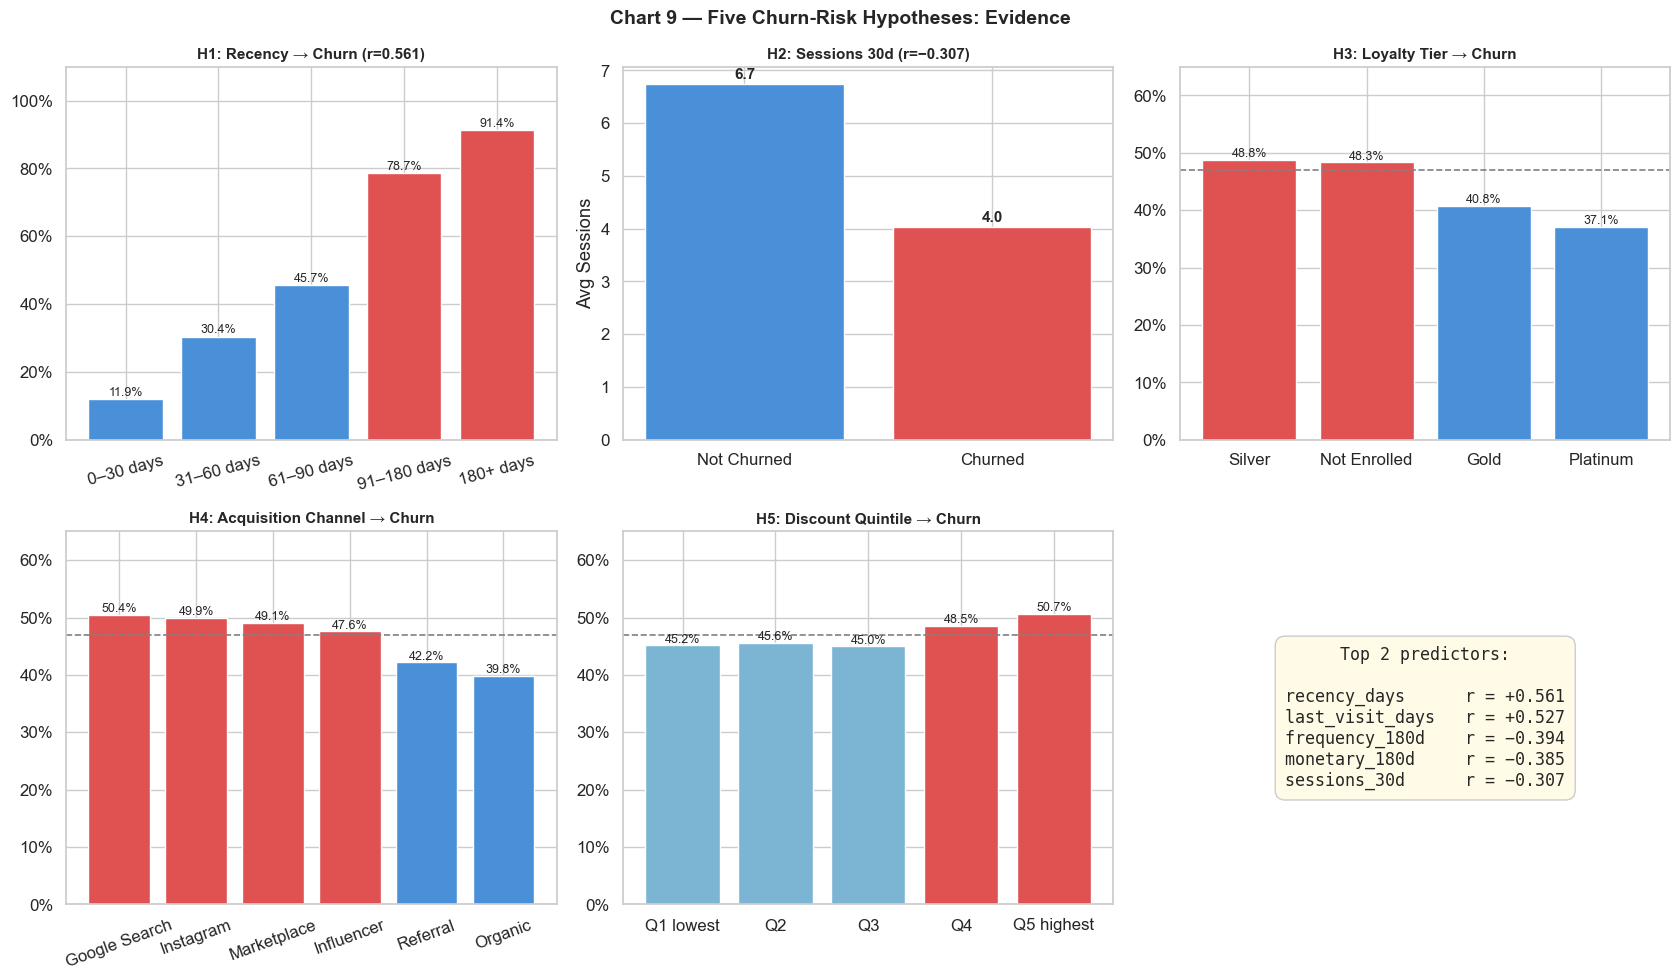

In [29]:
# Hypothesis evidence chart
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
af = axes.flatten()

# H1 Recency
rec_g = master2.groupby("recency_bucket", observed=True)["churn_next_60d"].mean().reset_index()
af[0].bar(rec_g["recency_bucket"], rec_g["churn_next_60d"],
          color=[COLORS["churned"] if r>0.47 else COLORS["retained"] for r in rec_g["churn_next_60d"]],
          edgecolor="white")
for i, row in rec_g.iterrows():
    af[0].text(list(rec_g.index).index(i), row["churn_next_60d"]+0.01,
               f"{row['churn_next_60d']:.1%}", ha="center", fontsize=9)
af[0].set_title("H1: Recency → Churn (r=0.561)", fontsize=11, fontweight="bold")
af[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
af[0].set_ylim(0, 1.1)
af[0].tick_params(axis="x", rotation=15)

# H2 Sessions
sm = master5.groupby("churn_next_60d")["sessions_30d"].mean()
af[1].bar(["Not Churned","Churned"], sm.values,
          color=[COLORS["retained"], COLORS["churned"]], edgecolor="white")
for i, v in enumerate(sm.values):
    af[1].text(i, v+0.1, f"{v:.1f}", ha="center", fontsize=11, fontweight="bold")
af[1].set_title("H2: Sessions 30d (r=−0.307)", fontsize=11, fontweight="bold")
af[1].set_ylabel("Avg Sessions")

# H3 Loyalty
lt_g = master_lt.groupby("loyalty_tier")["churn_next_60d"].mean().sort_values(ascending=False)
af[2].bar(lt_g.index, lt_g.values,
          color=[COLORS["churned"] if r>0.47 else COLORS["retained"] for r in lt_g.values],
          edgecolor="white")
af[2].axhline(labels["churn_next_60d"].mean(), color="gray", linestyle="--", linewidth=1.2)
for i, (t, r) in enumerate(lt_g.items()):
    af[2].text(i, r+0.005, f"{r:.1%}", ha="center", fontsize=9)
af[2].set_title("H3: Loyalty Tier → Churn", fontsize=11, fontweight="bold")
af[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
af[2].set_ylim(0, 0.65)

# H4 Acquisition channel
ch_g = master.groupby("acquisition_channel")["churn_next_60d"].mean().sort_values(ascending=False)
af[3].bar(ch_g.index, ch_g.values,
          color=[COLORS["churned"] if r>0.47 else COLORS["retained"] for r in ch_g.values],
          edgecolor="white")
af[3].axhline(labels["churn_next_60d"].mean(), color="gray", linestyle="--", linewidth=1.2)
for i, (ch, r) in enumerate(ch_g.items()):
    af[3].text(i, r+0.005, f"{r:.1%}", ha="center", fontsize=9)
af[3].set_title("H4: Acquisition Channel → Churn", fontsize=11, fontweight="bold")
af[3].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
af[3].set_ylim(0, 0.65)
af[3].tick_params(axis="x", rotation=20)

# H5 Discount
disc_g2 = master3.groupby("disc_bucket", observed=True)["churn_next_60d"].mean().reset_index()
af[4].bar(disc_g2["disc_bucket"], disc_g2["churn_next_60d"],
          color=[COLORS["churned"] if r>0.47 else COLORS["neutral"] for r in disc_g2["churn_next_60d"]],
          edgecolor="white")
af[4].axhline(labels["churn_next_60d"].mean(), color="gray", linestyle="--", linewidth=1.2)
for i, row in disc_g2.iterrows():
    af[4].text(list(disc_g2.index).index(i), row["churn_next_60d"]+0.005,
               f"{row['churn_next_60d']:.1%}", ha="center", fontsize=9)
af[4].set_title("H5: Discount Quintile → Churn", fontsize=11, fontweight="bold")
af[4].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
af[4].set_ylim(0, 0.65)

af[5].axis("off")
af[5].text(0.5, 0.5,
            "Top 2 predictors:\n\nrecency_days      r = +0.561\nlast_visit_days   r = +0.527\nfrequency_180d    r = −0.394\nmonetary_180d     r = −0.385\nsessions_30d      r = −0.307",
            ha="center", va="center", fontsize=12, family="monospace",
            transform=af[5].transAxes,
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#fffbe6", edgecolor="#ccc"))

plt.suptitle("Chart 9 — Five Churn-Risk Hypotheses: Evidence", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}/chart9_hypotheses.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Summary

| Finding | Value |
|---|---|
| Overall churn rate | 47.0% (1,127 / 2,400) |
| Strongest single predictor | `recency_days` (r=+0.561) |
| Second strongest predictor | `last_visit_days_ago` (r=+0.527) |
| Customers with no loyalty tier | 1,386 (57.8%) — highest addressable pool |
| Best acquisition channels | Organic (39.8%), Referral (42.2%) |
| Most effective CRM signal | `manual_priority_bucket` (high=74.7% churn) |
| Key data quality issues | 12 `_DUP` orders, 1,386 loyalty_tier nulls, 1,872 post-snapshot orders |

See `data_quality_report.md` and `business_memo.md` for full written summaries.
